<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/11_reinforcement_learning_qlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- nav-header -->
[⬅ Previous](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/10_bonus_pandas_tricks.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · **Notebook 11 of the course** · [Next: 12 — When data is too big for pandas ➡](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/12_big_data_beyond_pandas.ipynb)


# 🎮🩺 Notebook 11 — Reinforcement Learning: from a taxi game to a sepsis policy

> Every notebook so far **predicted** an outcome. This one is bolder: it tries to **choose the action**.
> We do it twice. First on a **toy game** where reinforcement learning works beautifully and you can watch
> it learn. Then we **build an environment out of the sepsis data** and run the *exact same algorithm* on
> it — and find out, hands-on, why the medical version is so much harder to trust.

**The plan**

| | |
|---|---|
| **Part 1 — it works** | Q-learning on a **Gymnasium** environment (the maintained "OpenAI Gym"). The agent goes from hopeless to perfect in about a second of training. |
| **Part 2 — the medical version** | Turn 1,696 real ICU stays into a **simulator with the same `reset()` / `step()` interface**, and train the same agent on it — an "AI Clinician" (after Komorowski *et al.*, *Nature Medicine* 2018). |
| **Part 3 — the reality check** | The sepsis agent reports a *spectacular* survival rate. We show, with a measurement, that most of it is **fiction** — and what the fix looks like. |

**⏱️ Time:** ≈60 min · **Prerequisites:** Notebooks 01–06 · **Level:** advanced / bonus (but kept gentle)

### ▶️ Run me first
Same setup cell as every notebook — run it and move on.

In [1]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 📥 Where the workshop data comes from — already set up for you, nothing to do.
# The data downloads automatically the first time you need it. If you were given a
# different link, just paste it in place of the one below. These forms all work:
#   • a Google-Drive folder link      • a Drive / Dropbox / OneDrive file link
#   • a folder URL ending in "/"      • a link straight to a .zip
# Set it to "" if you would rather upload the CSVs by hand.
# (The data is not in the GitHub repo: it is real de-identified patient data covered
#  by a data use agreement and may not be redistributed openly.)
WORKSHOP_DATA_URL = os.environ.get(
    "WORKSHOP_DATA_URL",
    "https://drive.google.com/drive/folders/1y7CparhrqdlCAZq6xQlj8fZda394fniD")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    """Look for the file on disk. Deliberately does NOT touch Google Drive, so the normal
    path never triggers an authorisation popup."""
    for p in [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]:
        if os.path.exists(p):
            return p
    return None

def _find_in_drive(name):
    """Only used as a fallback, because it mounts Drive (and that means a popup)."""
    cache = _drive_cache()
    if cache:
        p = os.path.join(cache, name)
        if os.path.exists(p):
            return p
    return None

def _direct_url(u):
    """Turn an ordinary Google-Drive / Dropbox / OneDrive *share* link into one that a
    plain HTTP client can actually download, so you can paste the link you were given."""
    import re
    m = (re.search(r"drive\.google\.com/file/d/([\w-]+)", u)
         or re.search(r"drive\.google\.com/(?:open|uc)\?(?:export=\w+&)?id=([\w-]+)", u))
    if m:
        return f"https://drive.google.com/uc?export=download&id={m.group(1)}"
    if "dropbox.com" in u:
        return u.split("?")[0] + "?dl=1"
    if "sharepoint.com" in u or "1drv.ms" in u:
        return u + ("&" if "?" in u else "?") + "download=1"
    return u

def _fetch(url, dest):
    import urllib.request, shutil as _sh
    req = urllib.request.Request(_direct_url(url), headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:
        _sh.copyfileobj(r, f)

_FOLDER = {"done": False}

def _gdrive_folder(name):
    """WORKSHOP_DATA_URL points at a Google-Drive *folder*: fetch it once with gdown
    (a folder cannot be downloaded with a plain HTTP request), then serve files from it."""
    dest = "_workshop_data"
    if not _FOLDER["done"]:
        _ensure({"gdown": "gdown"})
        import gdown
        print("⬇  fetching the workshop data from Google Drive (just once) …")
        gdown.download_folder(url=WORKSHOP_DATA_URL, output=dest, quiet=True, use_cookies=False)
        _FOLDER["done"] = True
    for root, _dirs, files in os.walk(dest):
        if name in files:
            return os.path.join(root, name)
    return None

def _try_download(name):
    """Fetch the data from WORKSHOP_DATA_URL, if one was configured."""
    u = (WORKSHOP_DATA_URL or "").strip()
    if not u:
        return None
    try:
        if "/drive/folders/" in u:
            return _gdrive_folder(name)
        if u.lower().split("?")[0].endswith(".zip"):
            import zipfile
            bundle = "_workshop_data.zip"
            if not os.path.exists(bundle):
                print("⬇  downloading the workshop data bundle …")
                _fetch(u, bundle)
            with zipfile.ZipFile(bundle) as z:      # flatten any folder inside the zip
                for member in z.namelist():
                    if os.path.basename(member) == name:
                        with z.open(member) as src, open(name, "wb") as dst:
                            dst.write(src.read())
                        return name
            print(f"  ({name} was not inside the bundle)")
            return None
        print(f"⬇  downloading {name} …")
        _fetch(u.rstrip("/") + "/" + name, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        for leftover in (name, "_workshop_data.zip"):
            if os.path.exists(leftover) and os.path.getsize(leftover) == 0:
                os.remove(leftover)
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV: looks on disk, then downloads it from WORKSHOP_DATA_URL, then checks
    your Google-Drive cache, and only as a last resort asks you to upload it — in which case
    it saves a copy to Drive so you never have to upload it twice."""
    p = _find(name)                       # 1. already on disk?
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)               # 2. the built-in download link
    if p:
        print(f"✓ loaded {name}")
        return pd.read_csv(p)
    p = _find_in_drive(name)              # 3. a copy you saved on a previous run
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    try:                                  # 4. last resort: upload it by hand
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Either paste your download link into WORKSHOP_DATA_URL at "
            f"the top of this cell, or put the CSV next to this notebook / in a data/ folder."
        )


In [2]:
# Gymnasium is the maintained successor of OpenAI Gym: a big box of ready-made
# environments that all speak the same two-method language, reset() and step().
_ensure({"gymnasium": "gymnasium"})
import gymnasium as gym

# The classic Taxi task was renamed v3 → v4 in recent Gymnasium; take whichever exists here.
TAXI = "Taxi-v4" if "Taxi-v4" in gym.registry else "Taxi-v3"
rng = np.random.default_rng(RANDOM_STATE)
print(f"gymnasium {gym.__version__} · using {TAXI}")

gymnasium 1.3.0 · using Taxi-v4


---
# Part 1 — reinforcement learning that works 🎮

## 🧭 The one picture you need

Supervised learning (Notebooks 05–08) *predicted* who dies; the model was a bystander. Reinforcement
learning (RL) asks the harder question: **what should we DO?** It is a loop between an **agent** and an
**environment**:

| RL term | In the taxi game | In the ICU |
|---|---|---|
| **Agent** | the driver we're training | the treatment *policy* ("AI clinician") |
| **Environment** | the 5×5 city grid | the patient |
| **State `s`** | where the taxi, passenger and destination are | the patient's condition this 4-h block |
| **Action `a`** | drive N/S/E/W · pick up · drop off | IV **fluid** dose × **vasopressor** dose |
| **Reward `r`** | −1 per step, **+20** for a correct drop-off, −10 for an illegal one | **+100** survive to 90 days, **−100** die |
| **Policy `π(s)`** | *in this situation, do this* — what we learn | *in this patient state, give this treatment* |

The agent's job is to maximise the **total reward over a whole episode**, not the next step. That is the
entire idea: act now, get paid later.

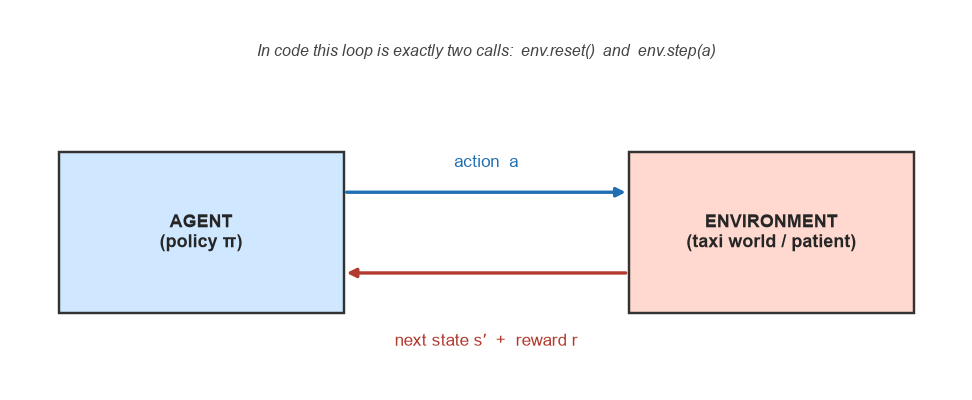

In [3]:
# A one-glance schematic of the agent–environment loop.
fig, ax = plt.subplots(figsize=(9, 3.8)); ax.axis("off")
def box(x, y, w, h, text, fc):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor="#333", lw=1.6))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center", fontsize=12, weight="bold")
box(0.05, 0.35, 0.30, 0.32, "AGENT\n(policy π)", "#cfe8ff")
box(0.65, 0.35, 0.30, 0.32, "ENVIRONMENT\n(taxi world / patient)", "#ffd9cf")
ax.annotate("", xy=(0.65, 0.59), xytext=(0.35, 0.59), arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#1f6fb2"))
ax.text(0.50, 0.64, "action  a", ha="center", fontsize=11, color="#1f6fb2")
ax.annotate("", xy=(0.35, 0.43), xytext=(0.65, 0.43), arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#b23a2e"))
ax.text(0.50, 0.31, "next state s′  +  reward r", ha="center", va="top", fontsize=11, color="#b23a2e")
ax.text(0.50, 0.86, "In code this loop is exactly two calls:  env.reset()  and  env.step(a)",
        ha="center", fontsize=10.5, style="italic", color="#444")
ax.set_xlim(0, 1); ax.set_ylim(0.2, 0.95); plt.tight_layout(); plt.show()

## 🚕 Meet the environment

**Taxi** is the classic tabular RL task. A taxi drives on a 5×5 grid, picks up a passenger at one of four
marked stops and drops them at another. Every step costs **−1** (so dawdling hurts), a correct drop-off pays
**+20**, an illegal pick-up/drop-off costs **−10**. There are **500 states** (25 squares × 5 passenger
positions × 4 destinations) and **6 actions**.

That's small enough that our agent can keep one number for every `(state, action)` pair — a **Q-table**.
It is *exactly* the shape we will use for sepsis later.

In [4]:
env = gym.make(TAXI, render_mode="ansi")            # "ansi" = render as text, perfect for notebooks
state, info = env.reset(seed=RANDOM_STATE)          # start a new episode
print(f"observation space: {env.observation_space}   action space: {env.action_space}")
print(f"starting state id: {state}\n")
print(env.render())        # 🟨 = taxi · blue letter = passenger · magenta letter = destination

next_state, reward, terminated, truncated, info = env.step(0)   # action 0 = drive south
print(f"step(0) → state {next_state}, reward {reward}, terminated={terminated}, truncated={truncated}")
print("\nThat is the whole API. Everything else in this notebook is built on these two calls.")

observation space: Discrete(500)   action space: Discrete(6)
starting state id: 386

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


step(0) → state 486, reward -1, terminated=False, truncated=False

That is the whole API. Everything else in this notebook is built on these two calls.


## 🎓 Q-learning in one formula

`Q[s, a]` answers: *"how much total reward do I expect if I take action `a` in state `s` and act well
afterwards?"* We start from all-zeros and nudge each entry toward the **Bellman target** — the reward we just
got, plus the best value available from where we landed:

$$Q[s,a] \;\leftarrow\; Q[s,a] + \alpha\,\big(\,\underbrace{r + \gamma\max_{a'}Q[s',a']}_{\text{target}} - Q[s,a]\,\big)$$

* **α** (learning rate) — how big a nudge.
* **γ** (discount, 0.99) — how much we care about the future.
* **ε-greedy** — with probability ε act **randomly** (explore), otherwise take the current best action
  (exploit). ε starts at 1.0 and decays: try everything early, then commit.

The `max` is the **off-policy** heart of Q-learning: it improves toward the *best* next action even while
behaving randomly. Remember that `max` — in Part 3 it is the villain.

In [5]:
def q_learning(env, n_episodes, alpha=0.5, gamma=0.99,
               eps_start=1.0, eps_end=0.05, eps_decay=0.999, seed=RANDOM_STATE):
    """Tabular Q-learning on ANY Gymnasium environment with discrete states and actions.
    Returns the Q-table and the total reward of every episode."""
    rng = np.random.default_rng(seed)
    nS, nA = env.observation_space.n, env.action_space.n
    Q = np.zeros((nS, nA))
    episode_returns, eps = [], eps_start

    for ep in range(n_episodes):
        s, _ = env.reset(seed=int(rng.integers(1 << 30)))
        total, done = 0.0, False
        while not done:
            a = int(rng.integers(nA)) if rng.random() < eps else int(np.argmax(Q[s]))   # ε-greedy
            s2, r, terminated, truncated, _ = env.step(a)
            best_next = 0.0 if terminated else Q[s2].max()          # nothing follows a terminal state
            Q[s, a] += alpha * (r + gamma * best_next - Q[s, a])    # ← the formula above
            s, total, done = s2, total + r, terminated or truncated
        eps = max(eps_end, eps * eps_decay)                          # explore less as we learn
        episode_returns.append(total)
    return Q, np.array(episode_returns)

import time
t0 = time.time()
Q_taxi, taxi_returns = q_learning(gym.make(TAXI), n_episodes=4000, alpha=0.5, eps_decay=0.9985)
print(f"Trained on 4,000 episodes in {time.time()-t0:.1f} s.")
print(f"Mean return   first 100 episodes: {taxi_returns[:100].mean():7.1f}")
print(f"Mean return    last 100 episodes: {taxi_returns[-100:].mean():7.1f}")

Trained on 4,000 episodes in 1.6 s.
Mean return   first 100 episodes:  -741.6
Mean return    last 100 episodes:     4.9


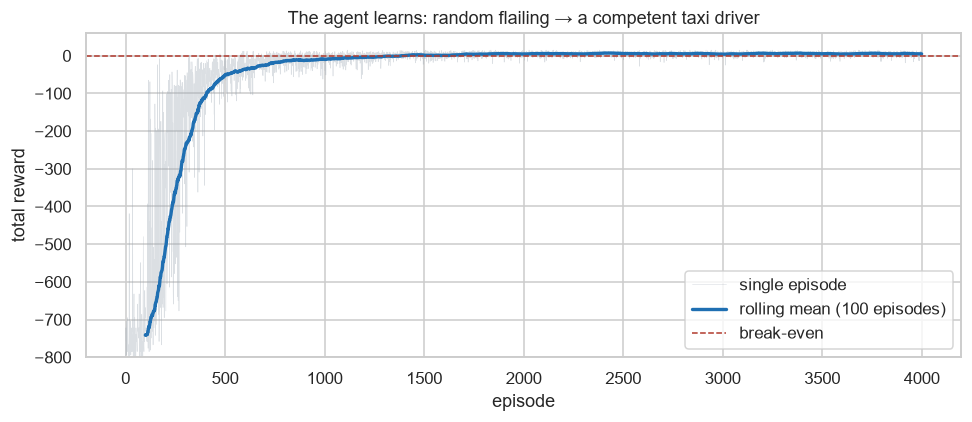

In [6]:
roll = pd.Series(taxi_returns).rolling(100).mean()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(taxi_returns, lw=.4, alpha=.35, color="#9aa5b1", label="single episode")
ax.plot(roll, lw=2.2, color="#1f6fb2", label="rolling mean (100 episodes)")
ax.axhline(0, color="#b23a2e", ls="--", lw=1, label="break-even")
ax.set_xlabel("episode"); ax.set_ylabel("total reward"); ax.set_ylim(-800, 60)
ax.set_title("The agent learns: random flailing → a competent taxi driver"); ax.legend()
plt.tight_layout(); plt.show()

That curve is what "it works" looks like. Now the honest test: switch exploration **off** and let the greedy
policy drive 200 fresh episodes.

trained (greedy):  mean return     7.8 · 100% of passengers delivered · 13.2 steps
random driver:     mean return  -762.7 · 4% of passengers delivered · 195.5 steps


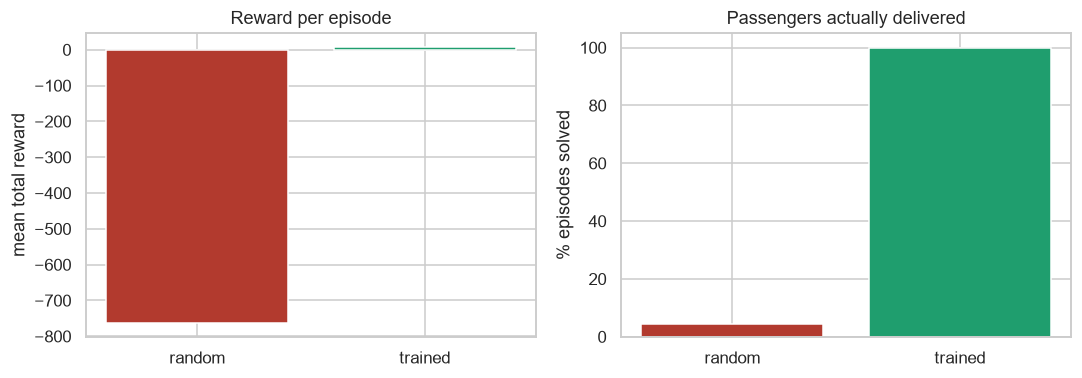

In [7]:
def evaluate(env, policy, n_episodes=200, seed=0):
    """Run a policy (a function state → action) and summarise how it did."""
    rng = np.random.default_rng(seed)
    returns, lengths, solved = [], [], 0
    for _ in range(n_episodes):
        s, _ = env.reset(seed=int(rng.integers(1 << 30)))
        total, steps, done, terminated = 0.0, 0, False, False
        while not done:
            s, r, terminated, truncated, _ = env.step(policy(s, rng))
            total += r; steps += 1; done = terminated or truncated
        returns.append(total); lengths.append(steps); solved += int(terminated)
    return {"return": float(np.mean(returns)), "steps": float(np.mean(lengths)),
            "solved": solved / n_episodes}

test_env = gym.make(TAXI)
greedy = evaluate(test_env, lambda s, rng: int(np.argmax(Q_taxi[s])))
random_pol = evaluate(test_env, lambda s, rng: int(rng.integers(test_env.action_space.n)))
print(f"trained (greedy):  mean return {greedy['return']:7.1f} · {greedy['solved']:.0%} of passengers delivered · {greedy['steps']:.1f} steps")
print(f"random driver:     mean return {random_pol['return']:7.1f} · {random_pol['solved']:.0%} of passengers delivered · {random_pol['steps']:.1f} steps")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(["random", "trained"], [random_pol["return"], greedy["return"]], color=["#b23a2e", "#1f9e6e"], edgecolor="white")
ax[0].set_ylabel("mean total reward"); ax[0].set_title("Reward per episode")
ax[1].bar(["random", "trained"], [100*random_pol["solved"], 100*greedy["solved"]], color=["#b23a2e", "#1f9e6e"], edgecolor="white")
ax[1].set_ylabel("% episodes solved"); ax[1].set_ylim(0, 105); ax[1].set_title("Passengers actually delivered")
plt.tight_layout(); plt.show()

### 👀 Watch it drive
The Q-table is just numbers — but you can replay it. Below is one full episode under the trained policy.

In [8]:
watch = gym.make(TAXI, render_mode="ansi")
s, _ = watch.reset(seed=7)
frames, total, done = [(watch.render(), None, 0.0)], 0.0, False
names = ["south", "north", "east", "west", "pick up", "drop off"]
while not done:
    a = int(np.argmax(Q_taxi[s]))
    s, r, terminated, truncated, _ = watch.step(a)
    total += r; done = terminated or truncated
    frames.append((watch.render(), names[a], r))
for i, (frame, action, r) in enumerate(frames):
    print(f"— step {i}" + (f"   (action: {action}, reward {r:+.0f})" if action else "   (start)"))
    print(frame)
print(f"Episode finished in {len(frames)-1} steps with total reward {total:+.0f}.")

— step 0   (start)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


— step 1   (action: south, reward -1)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

— step 2   (action: pick up, reward -1)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)

— step 3   (action: north, reward -1)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
|_| : | : |
|Y| : |B: |
+---------+
  (North)

— step 4   (action: north, reward -1)
+---------+
|R: | : :G|
| : | : : |
|_: : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

— step 5   (action: east, reward -1)
+---------+
|R: | : :G|
| : | : : |
| :_: : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)

— step 6   (action: east, reward -1)
+---------+
|R: | : :G|
| : | : : |
| : :_: : |
| | : | : |
|Y| : |B: |
+---------+
  (East)

— step 7   (action: north, reward -1)
+---------+
|R: | : :G|
| : |_: : |
| : : : : |
| | : | : |


> 🧠 **Why this worked.** Three things, and you should hold on to all of them:
> 1. We could **try** — 4,000 episodes' worth of wrong turns, none of them expensive.
> 2. The environment is the **real thing**, not a model of it. The rules of the taxi world *are* the rules.
> 3. The reward says exactly what we want (deliver fast, don't cheat).
>
> Now think about sepsis. We can't experiment on patients — so **1** is gone. We have no true simulator of
> a human being — so **2** is gone. And "survived / died" is a crude summary of a good outcome — so **3** is
> shaky too. Watch what happens when we press on anyway.

---
# Part 2 — building a sepsis environment out of data 🩺

We can't put an RL agent at a real bedside. So we do the next best thing: **learn a simulator from the
logged data** and let the agent practise in there. This is *model-based RL*, and it is genuinely how a lot
of medical RL is prototyped.

Three ingredients, each estimated from the 1,696 ICU stays:

1. **States** — cluster every 4-hour block into one of **100 "kinds of septic patient"** (+ two terminal
   states, `SURVIVE` and `DIE`).
2. **Actions** — the two dials at the bedside: **IV fluid × vasopressor**, 5 levels each → **25 actions**.
3. **Dynamics** — count what actually happened: *of all the times clinicians gave action `a` in state `s`,
   where did the patient end up next?* Those counts, normalised, are our transition probabilities.

⚠️ Note the trap already: ingredient 3 is only trustworthy for `(state, action)` pairs that were **tried
often**. Hold that thought until Part 3.

> 📎 **Which file the column names come from.** The two dials are `input_step` (IV fluid) and
> `max_dose_vaso` in the **time-series** file — one value per 4-hour block. The patient table from
> Notebook 04 has the summarised `vaso_max` (one value per *stay*) instead. That is not an oversight:
> an *action* only means something at a moment in time, so this notebook stays on the raw per-block
> rows throughout. If you port this code elsewhere, port the file with it.

In [9]:
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")     # quiets a harmless Windows warning
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = load_csv("sepsis_timeseries.csv")
df = df.sort_values(["icustayid", "bloc"]).reset_index(drop=True)   # RL needs events IN ORDER
print(f"{len(df):,} 4-hour blocks · {df['icustayid'].nunique():,} ICU stays")

# Winsorise the outlier-prone signals (as in Notebook 02) so one typo can't distort a whole group.
for c in ["Arterial_lactate", "Creatinine", "Shock_Index", "MeanBP", "HR"]:
    lo, hi = df[c].quantile([0.01, 0.99]); df[c] = df[c].clip(lo, hi)

# --- ACTIONS: fluid × vasopressor, 5 levels each (0 = none, positive doses split into quartiles) ---
def bin_5(series):
    x = series.to_numpy(float); out = np.zeros(len(x), int); pos = x > 0
    if pos.sum(): out[pos] = pd.qcut(x[pos], 4, labels=False, duplicates="drop") + 1
    return out
df["fluid_level"] = bin_5(df["input_step"])
df["vaso_level"]  = bin_5(df["max_dose_vaso"])
df["action"]      = df["fluid_level"] * 5 + df["vaso_level"]      # 0..24
N_ACTIONS = 25
print(f"{N_ACTIONS} actions · {(df['vaso_level']==0).mean():.0%} of blocks had no vasopressor at all")

✓ loaded data/sepsis_timeseries.csv
37,704 4-hour blocks · 1,696 ICU stays
25 actions · 85% of blocks had no vasopressor at all


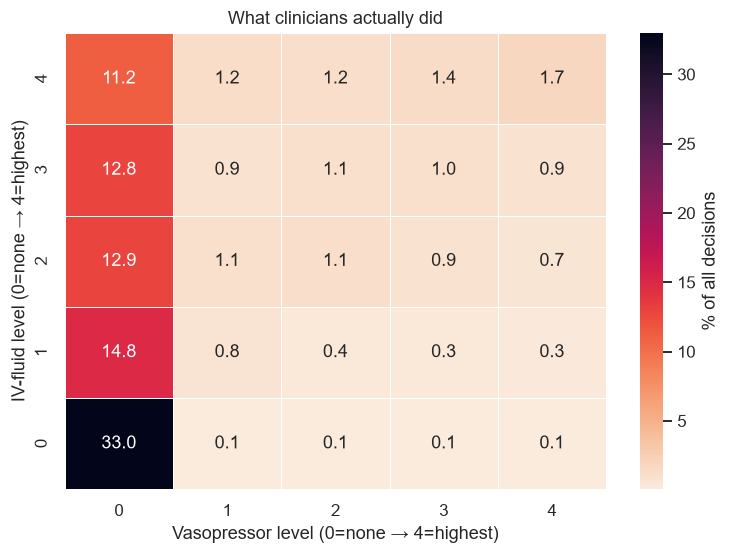

In [10]:
counts_grid = (df.groupby(["fluid_level","vaso_level"]).size()
               .reindex(pd.MultiIndex.from_product([range(5),range(5)], names=["fluid_level","vaso_level"]), fill_value=0)
               .unstack("vaso_level"))
fig, ax = plt.subplots(figsize=(7, 5.2))
sns.heatmap(100*counts_grid/counts_grid.values.sum(), annot=True, fmt=".1f", cmap="rocket_r",
            cbar_kws={"label": "% of all decisions"}, linewidths=.5, linecolor="white", ax=ax)
ax.set_xlabel("Vasopressor level (0=none → 4=highest)"); ax.set_ylabel("IV-fluid level (0=none → 4=highest)")
ax.invert_yaxis(); ax.set_title("What clinicians actually did"); plt.tight_layout(); plt.show()

> 🧠 **Remember this heatmap.** Real care piles up in the **left column** (no vasopressor) — pressors are held
> back for shock. The top-right corner (lots of both) was **almost never tried**, so our simulator knows
> essentially *nothing* about what happens there. It will still cheerfully make something up.

In [11]:
# --- STATES: 100 groups of "a recognisable kind of septic patient" -----------------
FEATURES = ["SOFA","SIRS","Arterial_lactate","MeanBP","HR","Creatinine","GCS","Shock_Index","age"]
N_STATES = 100
Xs = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(df[FEATURES]))
df["state"] = KMeans(N_STATES, random_state=RANDOM_STATE, n_init=3, max_iter=100).fit_predict(Xs)
SURVIVE, DIE = N_STATES, N_STATES + 1        # the two terminal states

sizes = np.bincount(df["state"], minlength=N_STATES)
print(f"{N_STATES} patient-state groups + 2 terminals · blocks per group: "
      f"min {sizes.min()}, median {int(np.median(sizes))}, max {sizes.max()}")

100 patient-state groups + 2 terminals · blocks per group: min 111, median 368, max 749


### 🔗 The dynamics: counting what happened next

Within a stay, each block flows to the next. At the **last** block the patient exits to `SURVIVE` or `DIE`,
and that is where the reward lands: **+100 / −100**, nothing in between. (Sparse, terminal-only reward =
*"I only care about the final outcome — you work out which states were on the road to it."*)

`build_model()` turns a set of stays into a transition table `P[s, a, s′]`. Where a `(state, action)` pair was
**never observed** we fall back to "whatever usually happens in this state" — an assumption we will put on
trial in Part 3.

In [12]:
def build_model(d):
    """Estimate a tabular MDP from patient trajectories: P[s,a,s'], the (s,a) counts, and the start-state mix."""
    s = d["state"].to_numpy(); a = d["action"].to_numpy()
    nxt     = d.groupby("icustayid")["state"].shift(-1)
    is_last = nxt.isna().to_numpy()
    died    = d["morta_90"].to_numpy()
    s_next  = np.where(is_last, np.where(died == 1, DIE, SURVIVE), nxt.fillna(0).to_numpy()).astype(int)

    C = np.zeros((N_STATES, N_ACTIONS, N_STATES + 2))
    np.add.at(C, (s, a, s_next), 1.0)                  # C[s,a,s'] = how often that transition was seen
    counts = C.sum(2)                                  # how often each (state, action) was tried at all
    marginal = C.sum(1)                                # what happens in this state under usual care
    P = np.where(counts[:, :, None] > 0,
                 C / np.maximum(counts, 1)[:, :, None],                                  # observed
                 (marginal / np.maximum(marginal.sum(1, keepdims=True), 1))[:, None, :]) # guessed
    start = np.bincount(d.groupby("icustayid")["state"].head(1).to_numpy(), minlength=N_STATES).astype(float)
    return P, counts, start / start.sum()

P, counts, start_dist = build_model(df)
print(f"(state, action) cells ever tried: {(counts > 0).mean():.0%}   ·   tried ≥ 5 times: {(counts >= 5).mean():.0%}")
print(f"→ {(counts == 0).sum():,} of the {counts.size:,} cells have NO data. The simulator guesses there.")

(state, action) cells ever tried: 67%   ·   tried ≥ 5 times: 37%
→ 823 of the 2,500 cells have NO data. The simulator guesses there.


### 🕹️ Wrapping it as a Gymnasium environment

Now the payoff of Part 1: we give the ICU the **same interface as the taxi game**. `reset()` admits a new
simulated patient; `step(action)` gives them 4 hours of treatment and returns the new state — and, if the
stay ends, ±100.

In [13]:
class SepsisEnv(gym.Env):
    """An ICU 'game': every step is one 4-hour block of treatment for a simulated septic patient."""
    def __init__(self, P, start_dist, max_blocks=50):     # 50 blocks ≈ 8 days
        self.P, self.start_dist, self.max_blocks = P, start_dist, max_blocks
        self.observation_space = gym.spaces.Discrete(N_STATES)
        self.action_space      = gym.spaces.Discrete(N_ACTIONS)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)                                    # seeds self.np_random
        self.s = int(self.np_random.choice(N_STATES, p=self.start_dist))
        self.t = 0
        return self.s, {}

    def step(self, action):
        s_next = int(self.np_random.choice(N_STATES + 2, p=self.P[self.s, action]))
        self.t += 1
        terminated = s_next >= N_STATES
        reward = 0.0 if not terminated else (100.0 if s_next == SURVIVE else -100.0)
        if not terminated:
            self.s = s_next
        info = {"outcome": None if not terminated else ("survived" if s_next == SURVIVE else "died")}
        return self.s, reward, terminated, self.t >= self.max_blocks, info

sepsis_env = SepsisEnv(P, start_dist)
behaviour  = counts / np.maximum(counts.sum(1, keepdims=True), 1)    # π_behaviour(a | s), straight from the data
clinician_policy = lambda s, r: int(r.choice(N_ACTIONS, p=behaviour[s]))

# One simulated patient, treated the way clinicians treated patients like them.
group = df.groupby("state").agg(lactate=("Arterial_lactate","mean"), MAP=("MeanBP","mean"))
s, _ = sepsis_env.reset(seed=3); rows = []
for t in range(sepsis_env.max_blocks):
    a = clinician_policy(s, rng)
    rows.append({"block": t, "hours": 4*t, "state": s, "lactate": group.loc[s,"lactate"],
                 "MAP": group.loc[s,"MAP"], "fluid": a // 5, "vaso": a % 5})
    s, reward, terminated, truncated, info = sepsis_env.step(a)
    if terminated or truncated: break
traj = pd.DataFrame(rows).round(1)
print(traj.head(8).to_string(index=False))
if len(traj) > 8: print(f"  … ({len(traj)-8} more blocks)")
print(f"→ after {len(traj)} blocks: {info['outcome'] or 'still in ICU'}  (reward {reward:+.0f})")

 block  hours  state  lactate  MAP  fluid  vaso
     0      0      7      3.0 79.6      3     0
     1      4      7      3.0 79.6      0     0
     2      8     54      1.3 81.0      3     0
     3     12     43      1.3 80.1      3     0
     4     16     12      1.2 94.0      0     0
     5     20     12      1.2 94.0      4     0
     6     24     22      1.4 89.7      3     0
     7     28     13      1.4 93.8      3     0
  … (7 more blocks)
→ after 15 blocks: survived  (reward +100)


### ✅ Does the simulator behave like the real ICU?

Before trusting it at all, replay the **clinicians' own policy** on 2,000 simulated patients — sampling actions
with exactly the frequencies doctors used in each state — and check that the simulated survival rate matches
reality.

In [14]:
def simulate(env, policy, n_patients=2000, seed=1):
    """Run a policy on n simulated patients; report what fraction survived / died / never resolved."""
    rng_local = np.random.default_rng(seed)
    out = {"survived": 0, "died": 0, "still in ICU": 0}; returns = []
    for _ in range(n_patients):
        s, _ = env.reset(seed=int(rng_local.integers(1 << 30)))
        done = terminated = False; total = 0.0
        while not done:
            s, r, terminated, truncated, info = env.step(policy(s, rng_local))
            total += r; done = terminated or truncated
        out["still in ICU" if not terminated else info["outcome"]] += 1
        returns.append(total)
    return {k: v / n_patients for k, v in out.items()} | {"mean return": float(np.mean(returns))}

clin = simulate(sepsis_env, clinician_policy)
real_survival = 1 - df.groupby("icustayid")["morta_90"].first().mean()

print(f"Real data      — survived: {real_survival:.1%}")
print(f"Simulated care — survived: {clin['survived']:.1%} · died: {clin['died']:.1%} · "
      f"still in ICU after 8 days: {clin['still in ICU']:.1%}")
print(f"                 of the stays that resolved: {clin['survived']/(clin['survived']+clin['died']):.1%} survived")

Real data      — survived: 81.8%
Simulated care — survived: 76.0% · died: 14.8% · still in ICU after 8 days: 9.2%
                 of the stays that resolved: 83.7% survived


Close enough to be interesting. Now — **the same `q_learning` function as the taxi**, pointed at the ICU.
Nothing about the algorithm changes; only the environment does.

Trained on 20,000 simulated patients in 3.1 s.


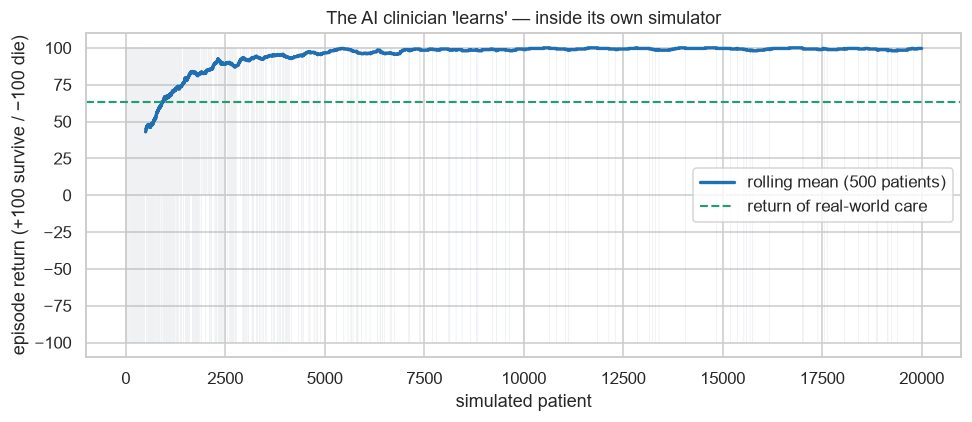

In [15]:
t0 = time.time()
Q_sepsis, sepsis_returns = q_learning(sepsis_env, n_episodes=20000, alpha=0.1, eps_decay=0.9997)
print(f"Trained on 20,000 simulated patients in {time.time()-t0:.1f} s.")

roll = pd.Series(sepsis_returns).rolling(500).mean()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sepsis_returns, lw=.3, alpha=.15, color="#9aa5b1")
ax.plot(roll, lw=2.2, color="#1f6fb2", label="rolling mean (500 patients)")
ax.axhline(100*real_survival - 100*(1-real_survival), color="#1f9e6e", ls="--", lw=1.4,
           label="return of real-world care")
ax.set_xlabel("simulated patient"); ax.set_ylabel("episode return (+100 survive / −100 die)")
ax.set_title("The AI clinician 'learns' — inside its own simulator"); ax.legend()
plt.tight_layout(); plt.show()

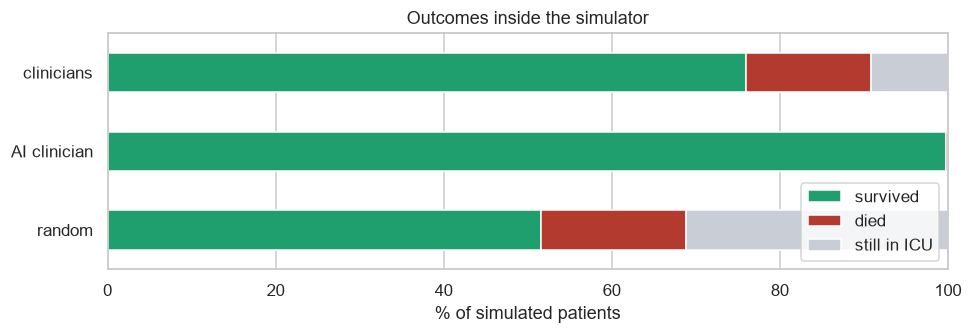

              survived  died  still in ICU
clinicians        76.0  14.8           9.2
AI clinician      99.8   0.2           0.0
random            51.6  17.2          31.2

🎉 The AI clinician 'saves' 23.8% more patients than real care. Nature paper, here we come.


In [16]:
policy_ai = Q_sepsis.argmax(1)                       # greedy: best action per patient state
ai   = simulate(sepsis_env, lambda s, r: int(policy_ai[s]))
rand = simulate(sepsis_env, lambda s, r: int(r.integers(N_ACTIONS)))

res = pd.DataFrame([clin, ai, rand], index=["clinicians", "AI clinician", "random"])[
        ["survived", "died", "still in ICU"]] * 100
ax = res.plot(kind="barh", stacked=True, figsize=(9, 3.2),
              color={"survived": "#1f9e6e", "died": "#b23a2e", "still in ICU": "#c9ced6"}, edgecolor="white")
ax.set_xlabel("% of simulated patients"); ax.set_title("Outcomes inside the simulator"); ax.invert_yaxis()
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
print(res.round(1).to_string())
print(f"\n🎉 The AI clinician 'saves' {ai['survived']-clin['survived']:.1%} more patients than real care. "
      f"Nature paper, here we come.")

---
# Part 3 — the reality check 🔍

A ~24-point jump in survival, from a Q-table that trained in a couple of seconds. If that were real it would
be the biggest result in critical care medicine. It is not real, and the data can tell us why.

**Question 1: how much evidence is behind the AI's advice?** For each state, how many times was the action it
recommends *actually tried* in that state?

AI's recommended action was tried a MEDIAN of 2 times in that state.
   → in 71/100 states it was seen fewer than 5 times.
Doctors' usual action, for comparison: median 117 observations.
The AI picks the doctors' usual action in 1% of states.


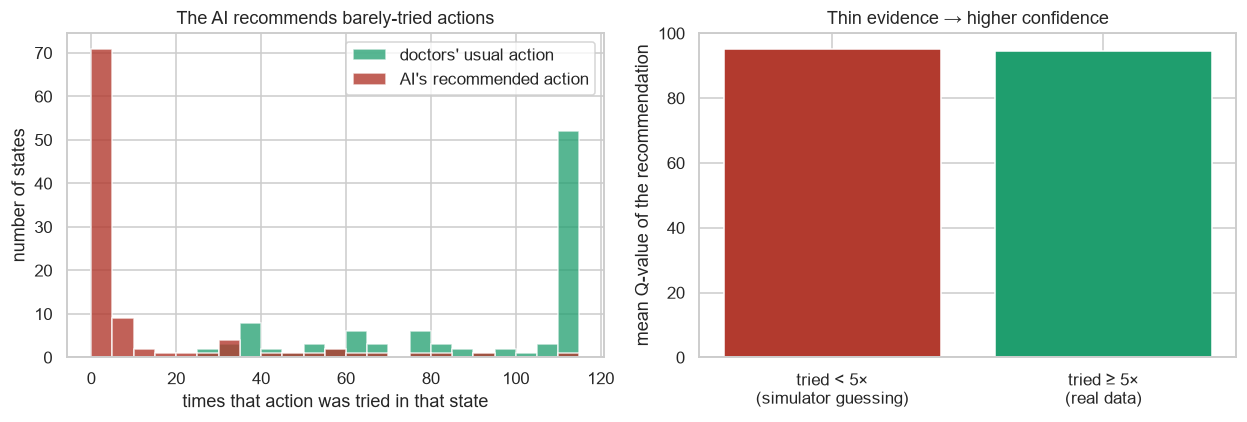

In [17]:
rec_support  = counts[np.arange(N_STATES), policy_ai]        # data behind the AI's choice
clin_modal   = counts.argmax(1)                              # doctors' most common action per state
clin_support = counts[np.arange(N_STATES), clin_modal]

print(f"AI's recommended action was tried a MEDIAN of {int(np.median(rec_support))} times in that state.")
print(f"   → in {(rec_support < 5).sum()}/{N_STATES} states it was seen fewer than 5 times.")
print(f"Doctors' usual action, for comparison: median {int(np.median(clin_support))} observations.")
print(f"The AI picks the doctors' usual action in {(policy_ai == clin_modal).mean():.0%} of states.")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
bins = np.arange(0, 120, 5)
ax[0].hist(np.clip(clin_support, 0, 115), bins=bins, alpha=.75, label="doctors' usual action", color="#1f9e6e")
ax[0].hist(np.clip(rec_support, 0, 115),  bins=bins, alpha=.80, label="AI's recommended action", color="#b23a2e")
ax[0].set_xlabel("times that action was tried in that state"); ax[0].set_ylabel("number of states")
ax[0].set_title("The AI recommends barely-tried actions"); ax[0].legend()
thin = rec_support < 5
ax[1].bar(["tried < 5×\n(simulator guessing)", "tried ≥ 5×\n(real data)"],
          [Q_sepsis[np.arange(N_STATES), policy_ai][thin].mean(),
           Q_sepsis[np.arange(N_STATES), policy_ai][~thin].mean()],
          color=["#b23a2e", "#1f9e6e"], edgecolor="white")
ax[1].set_ylabel("mean Q-value of the recommendation"); ax[1].set_title("Thin evidence → higher confidence")
plt.tight_layout(); plt.show()

So the agent's boldest advice sits on the **thinnest evidence** — and those are exactly the cells where our
`build_model()` *made the dynamics up*. The `max` in Q-learning then hunts for precisely those cells: any
action whose invented transition looks good gets picked and reinforced. The agent isn't discovering medicine,
it is **farming the bugs in our simulator**.

**Question 2: can we prove that?** Yes — the same way we prove anything else in this course. **Hold patients
out.** Build two simulators from two disjoint halves of the stays, train in the first, and test in the second.
A policy that found real medicine transfers. A policy that found simulator bugs does not.

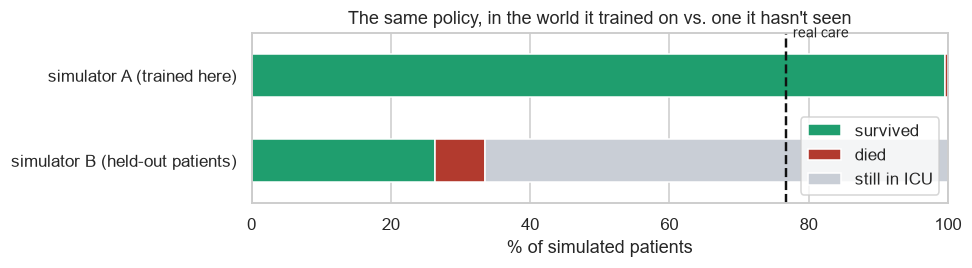

                                 survived  died  still in ICU
simulator A (trained here)           99.6   0.4           0.0
simulator B (held-out patients)      26.3   7.3          66.4

Survival: 99.6% in its own simulator → 26.3% on held-out patients (real care there: 76.8%).


In [18]:
ids = df["icustayid"].unique().copy()
np.random.default_rng(0).shuffle(ids)
half = set(ids[:len(ids)//2])
df_A, df_B = df[df["icustayid"].isin(half)], df[~df["icustayid"].isin(half)]

P_A, counts_A, start_A = build_model(df_A)          # simulator A — the agent's training world
P_B, counts_B, start_B = build_model(df_B)          # simulator B — different patients, same rules of medicine
env_A, env_B = SepsisEnv(P_A, start_A), SepsisEnv(P_B, start_B)

Q_A, _ = q_learning(env_A, n_episodes=20000, alpha=0.1, eps_decay=0.9997)
policy_A = Q_A.argmax(1)
behaviour_B = counts_B / np.maximum(counts_B.sum(1, keepdims=True), 1)

trained_on_A = {"simulator A (trained here)": simulate(env_A, lambda s, r: int(policy_A[s])),
                "simulator B (held-out patients)": simulate(env_B, lambda s, r: int(policy_A[s]))}
clin_B = simulate(env_B, lambda s, r: int(r.choice(N_ACTIONS, p=behaviour_B[s])))

tbl = pd.DataFrame(trained_on_A).T[["survived", "died", "still in ICU"]] * 100
ax = tbl.plot(kind="barh", stacked=True, figsize=(9, 2.6),
              color={"survived": "#1f9e6e", "died": "#b23a2e", "still in ICU": "#c9ced6"}, edgecolor="white")
ax.axvline(100*clin_B["survived"], color="#111", ls="--", lw=1.6)
ax.text(100*clin_B["survived"]+1, -0.45, "real care", fontsize=9)
ax.set_xlabel("% of simulated patients"); ax.invert_yaxis()
ax.set_title("The same policy, in the world it trained on vs. one it hasn't seen")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
print(tbl.round(1).to_string())
print(f"\nSurvival: {trained_on_A['simulator A (trained here)']['survived']:.1%} in its own simulator → "
      f"{trained_on_A['simulator B (held-out patients)']['survived']:.1%} on held-out patients "
      f"(real care there: {clin_B['survived']:.1%}).")

> 🧠 **There it is.** The miracle policy evaporates the moment the simulator is built from *different*
> patients. Two failures show up at once:
> * **Model exploitation** — it learned the quirks of simulator A, not medicine. This is the offline-RL
>   version of overfitting, and it is why a great-looking learned value is **not** evidence a policy works.
> * **Reward hacking / stalling** — look at the grey bar. With +100 for survival, −100 for death and **0 for
>   everything else**, keeping a patient forever in limbo scores better than risking death. Our reward never
>   said "and please get them out of the ICU", so the agent doesn't.
>
> Neither problem is visible if you only ever look at the training environment — which is exactly what
> reporting "the AI achieved 99% survival" does.

### 🧪 The fix, in miniature: only trust what was actually tried
If the trouble is recommending actions nobody tried, then **forbid** them: let the policy pick only actions
seen at least **K times** in that state, and where no action clears the bar, fall back to what clinicians
usually did. This is a poor-man's **BCQ / CQL** — the real offline-RL methods are built on exactly this
instinct: distrust unsupported actions.

`K` is the interesting knob. Small `K` = bold and unfounded; large `K` = safe and unoriginal. Let's measure
the whole trade-off instead of arguing about it.

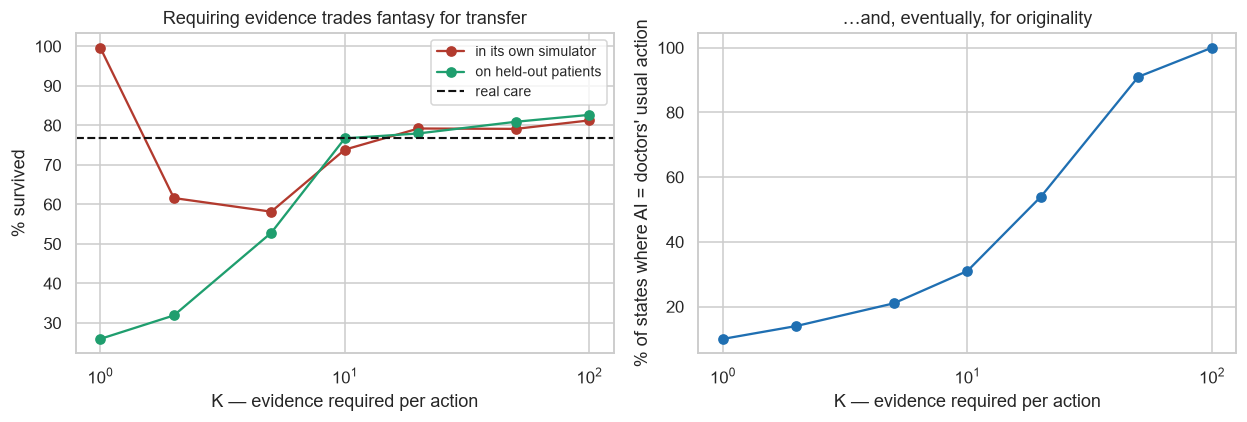

     own simulator A  held-out simulator B  agrees with doctors %  states copying doctors
K                                                                                        
1               99.6                  26.0                   10.0                       0
2               61.6                  31.9                   14.0                       0
5               58.2                  52.8                   21.0                       0
10              73.9                  76.7                   31.0                       0
20              79.2                  78.0                   54.0                       2
50              79.1                  80.9                   91.0                      39
100             81.2                  82.6                  100.0                      81


In [19]:
def constrain(Q, counts, K):
    """Let the policy choose only actions tried >= K times; elsewhere copy the clinicians."""
    Qc = Q.copy(); Qc[counts < K] = -1e9
    fallback = (counts < K).all(1)
    pol = Qc.argmax(1); pol[fallback] = counts.argmax(1)[fallback]
    return pol, fallback

modal_A = counts_A.argmax(1)
rows = []
for K in [1, 2, 5, 10, 20, 50, 100]:
    pol, fallback = constrain(Q_A, counts_A, K)
    rows.append({"K": K,
                 "own simulator A": 100*simulate(env_A, lambda s, r: int(pol[s]))["survived"],
                 "held-out simulator B": 100*simulate(env_B, lambda s, r: int(pol[s]))["survived"],
                 "agrees with doctors %": 100*(pol == modal_A).mean(),
                 "states copying doctors": fallback.sum()})
sweep = pd.DataFrame(rows).set_index("K")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4), sharex=True)
ax[0].plot(sweep.index, sweep["own simulator A"], "-o", color="#b23a2e", label="in its own simulator")
ax[0].plot(sweep.index, sweep["held-out simulator B"], "-o", color="#1f9e6e", label="on held-out patients")
ax[0].axhline(100*clin_B["survived"], color="#111", ls="--", lw=1.4, label="real care")
ax[0].set_xscale("log"); ax[0].set_xlabel("K — evidence required per action"); ax[0].set_ylabel("% survived")
ax[0].set_title("Requiring evidence trades fantasy for transfer"); ax[0].legend(fontsize=9)
ax[1].plot(sweep.index, sweep["agrees with doctors %"], "-o", color="#1f6fb2")
ax[1].set_xscale("log"); ax[1].set_xlabel("K — evidence required per action")
ax[1].set_ylabel("% of states where AI = doctors' usual action")
ax[1].set_title("…and, eventually, for originality")
plt.tight_layout(); plt.show()
print(sweep.round(1).to_string())

> 🧠 **This is the whole lesson**, and it's in that left panel. At **K = 1** the agent is a genius in its own
> simulator and a disaster anywhere else. Push `K` up and the two curves come together: once every recommended
> action has real evidence behind it, the policy finally **transfers to patients it never trained on** —
> landing right about where real clinicians already are.
>
> The right panel is the price. By **K = 100** the "AI" agrees with the doctors' usual action in every single
> state: it has stopped being an AI clinician and become a lookup table of what doctors do. Somewhere in the
> middle sits the only honest claim this notebook can make — *"about as good as current care, on the states
> where we have data."* That tension — **evidence versus originality** — is the central design problem of
> offline RL, and it is why BCQ, CQL and friends exist.

## ⚠️ So — can we use this at the bedside? **No.** Here's the full list

**1. Our environment is a model fitted to the same data.** In the taxi game the environment *was* the truth.
Here it is a 100-state cartoon of human physiology estimated from 1,696 patients — a third of its
`(state, action)` cells were never observed at all, and only ~37% were seen five times or more. Training in it and reporting the score is circular.

**2. Off-policy evaluation is genuinely hard.** The honest tools all have teeth: **importance sampling
(IS/WIS)** — variance explodes when the policies disagree, which is our case; **Fitted Q Evaluation (FQE)** —
only as good as its own extrapolation. Each can report a confident number that is simply wrong.

**3. Distribution shift & dead ends.** As we measured: high value on `(state, action)` pairs barely seen, and
a `max` that actively seeks them out.

**4. Reward mis-specification.** **+100 survive / −100 die and nothing else** is blind to bleeding, limb
ischaemia from pressors, fluid overload, delirium, quality of life — and, as we saw, it *rewards stalling*.
Optimise a narrow proxy, get a policy that games it.

**5. Tiny, single-centre, discretised data.** ~1,700 down-sampled stays, 100 states, 25 actions. Real
AI-Clinician-scale work uses tens of thousands of patients and *still* draws serious methodological fire.

**6. Ethics.** A wrong *prediction* costs a little trust; a wrong *prescription* can cost a life. Bedside RL
demands prospective validation, uncertainty-aware evaluation, human oversight, and ultimately randomised
trials.

**📚 Read both sides**
- Komorowski M, Celi LA, Badawi O, Gordon AC, Faisal AA. *The Artificial Intelligence Clinician learns optimal
  treatment strategies for sepsis in intensive care.* **Nature Medicine** 24, 1716–1720 (2018).
- Gottesman O, Johansson F, Komorowski M, *et al.* *Guidelines for reinforcement learning in healthcare.*
  **Nature Medicine** 25, 16–18 (2019). — the rebuttal, and required reading before you try this for real.

## ✏️ Your turn

### Exercise 1 — how far ahead does the agent need to see?
Retrain the taxi agent with a short-sighted discount — **`gamma=0.5`**, then **`gamma=0.2`** — and evaluate
each greedily. Which one breaks, and why? *(Think about how many steps separate the taxi from its +20.)*

In [20]:
# TODO: Q2, _ = q_learning(gym.make(TAXI), 4000, alpha=0.5, gamma=..., eps_decay=0.9985)
#       then evaluate(test_env, lambda s, rng: int(np.argmax(Q2[s])))

<details><summary>💡 Show solution</summary>

```python
for g in (0.99, 0.5, 0.2):
    Qg, _ = q_learning(gym.make(TAXI), 4000, alpha=0.5, gamma=g, eps_decay=0.9985)
    print(f"gamma={g}:", evaluate(test_env, lambda s, rng: int(np.argmax(Qg[s]))))
# gamma=0.5 still works: a reward 10 steps away is worth ~0.1% of face value, but Taxi also pays
# -1 every step, and that dense signal alone points roughly the right way.
# gamma=0.2 falls apart — the +20 no longer reaches the states that lead to it, so the taxi wanders.
# Now notice: in our sepsis env NOTHING happens until the end. There is no dense -1 to fall back on,
# so a far-sighted discount isn't a nicety there, it's the only thing carrying the signal.
```
</details>

### Exercise 2 — stop the stalling
On held-out patients the AI parked most of them in the ICU forever, because limbo scores 0 and dying scores
−100. Give every 4-hour block a small cost (say **−1**) by subclassing `SepsisEnv`, retrain on simulator A,
and see what happens to the "still in ICU" fraction **in simulator B**.

In [21]:
# TODO: class CostlyCareEnv(SepsisEnv) that overrides step() to subtract 1 from the reward,
#       then q_learning(...) on it and simulate() its greedy policy in env_B.

<details><summary>💡 Show solution</summary>

```python
class CostlyCareEnv(SepsisEnv):
    def step(self, action):
        s, r, terminated, truncated, info = super().step(action)
        return s, r - 1.0, terminated, truncated, info      # every block in the ICU costs something

Q_cost, _ = q_learning(CostlyCareEnv(P_A, start_A), 20000, alpha=0.1, eps_decay=0.9997)
pol_cost = Q_cost.argmax(1)
print("no per-block cost, on held-out patients:", simulate(env_B, lambda s, r: int(policy_A[s])))
print("with a per-block cost,      same test:", simulate(env_B, lambda s, r: int(pol_cost[s])))
# Stalling drops a lot (roughly two thirds of patients stuck → under a half) and survival rises,
# because the agent now wants patients OUT. But it is still nowhere near real care: the cost fixed
# the symptom we noticed, not the model exploitation underneath. Every behaviour you don't want has
# to be written into the reward — and you will always forget one. That's reward mis-specification,
# and it does not get easier in real medicine.
```
</details>

### Exercise 3 — when does the AI stop being an AI?
In the sweep table, at which **K** does the policy agree with the doctors' usual action in **every** state?
Then take a milder setting (`K = 10`) and look at the states where it still disagrees: how much evidence
stands behind the AI's choice there, compared with the doctors'?

In [22]:
# TODO: read `sweep`. Then take the K=10 policy with constrain(Q_A, counts_A, 10) and, in the states
#       where it disagrees with the doctors, compare the evidence behind its choice vs. behind theirs.

<details><summary>💡 Show solution</summary>

```python
print(sweep[["agrees with doctors %", "states copying doctors"]])
pol10, _ = constrain(Q_A, counts_A, 10)
modal_A = counts_A.argmax(1)
ix = np.arange(N_STATES); differs = pol10 != modal_A
print(f"K=10 disagrees with the doctors in {differs.sum()}/{N_STATES} states")
print("   median times the AI's choice was tried there   :", int(np.median(counts_A[ix, pol10][differs])))
print("   median times the doctors' choice was tried there:", int(np.median(counts_A[ix, modal_A][differs])))
# K=100 is the first row with 100% agreement: the 'AI' has become a lookup table of what doctors do.
# Below that, everything it adds sits on actions tried a few dozen times, against a clinician default
# tried several times more often. That IS the trade-off — the policy's originality lives exactly where
# its evidence is thinnest, by construction. No tuning removes it; only more (and more varied) data does.
```
</details>

## ✅ Recap

**Part 1 — RL works when you can experiment.** Tabular Q-learning, ~40 lines, took a taxi agent from
−760 reward to a perfect delivery record in under a second of training, using nothing but `env.reset()` and
`env.step(a)`.

**Part 2 — we built an ICU with the same interface.** 100 patient states × 25 fluid/vasopressor actions,
transition probabilities counted from 1,696 real stays, ±100 at discharge or death. The *same* `q_learning`
function then reported a survival rate far above real care.

**Part 3 — and that number was fiction.** We measured why:
- its recommended actions had been tried a **median of ~2 times** — exactly the cells where our simulator
  invented the physics, and Q-learning's `max` hunts for them;
- we **held out half the patients**, rebuilt the simulator from the other half, and watched near-perfect
  survival collapse to far below real care;
- it also learned to **stall** — parking patients in the ICU forever — because our reward never penalised a
  patient who neither recovers nor dies;
- forcing it to use only **well-tried actions** (BCQ-lite) removed the fantasy, and with enough evidence
  required, the policy finally transferred to unseen patients — at which point it looked a lot like the
  doctors it was supposed to improve on.

**The transferable skill:** an RL result is only as good as the environment it was evaluated in. In games the
environment is the truth. In medicine it is a model built from the same data you trained on — so *always*
ask what would happen on patients the simulator never saw.

## ➡️ Going further (responsibly)
- **Other Gymnasium environments** to practise on: `FrozenLake-v1` (stochastic gridworld), `CliffWalking-v1`
  (the classic Q-learning vs SARSA demo), then `CartPole-v1` when you're ready for function approximation.
- **Offline-RL algorithms that distrust unseen actions:** Conservative Q-Learning (**CQL**), Batch-Constrained
  Q-learning (**BCQ**) — the grown-up version of our support constraint.
- **Honest evaluation:** Fitted Q Evaluation (**FQE**), weighted importance sampling with **confidence
  intervals** — never a single point estimate.
- **Tooling:** [`d3rlpy`](https://github.com/takuseno/d3rlpy) implements CQL/BCQ/FQE on datasets exactly like
  the one we built here.

> 🎓 **You've finished the course.** You can clean messy clinical time series, engineer leakage-safe features,
> build and *honestly* evaluate models, explain them, and reason about the promise **and perils** of
> prescriptive AI. That last skill — measured skepticism, backed by checking the data — is the one to keep.

<!-- nav-footer -->
---

### ➡️ Next up — Notebook 12: When data is too big for pandas

<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/12_big_data_beyond_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open Notebook 12 in Colab" height="32"/></a>

👉 **[Continue to Notebook 12 — When data is too big for pandas](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/12_big_data_beyond_pandas.ipynb)**

[⬅ Back to Notebook 10](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/10_bonus_pandas_tricks.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · [📁 The course on GitHub](https://github.com/lorenzkap/ML2026)